# SonicDNA · EDA Notebook (01)

Exploratory analysis of the cleaned Spotify Tracks Dataset.

Figures here populate the report's **Data Visualization** chapter:

1. 9 audio-feature distributions (data layer)
2. Pearson correlation heatmap (data layer)
3. Meta-genre frequency bar (data layer)
4. PCA 2-D global map colored by mood cluster (model layer)
5. KMeans 8 centroids radar comparison (model layer)

All figures are saved to `../models/figures/` so the report can pick
them up directly.

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make the pipeline package importable from the notebook.
NB_DIR = Path.cwd()
SOURCE_ROOT = NB_DIR.parent
sys.path.insert(0, str(SOURCE_ROOT))

from pipeline.config import (
    FEATURE_COLS, MODELS_DIR, MOOD_KMEANS_PATH,
    PROCESSED_PARQUET_PATH, SCALER_PATH,
)

FIG_DIR = MODELS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110

df = pd.read_parquet(PROCESSED_PARQUET_PATH)
print(f"Loaded {len(df):,} tracks across {df['meta_genre'].nunique()} meta-genres")
df.head(3)

Loaded 89,740 tracks across 11 meta-genres


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,acousticness_z,instrumentalness_z,liveness_z,speechiness_z,tempo_z,popularity_z,mood_cluster,pca_x,pca_y,mood_label
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,...,-0.875166,-0.535482,0.723656,0.490458,-1.133599,1.933925,0,0.819560,1.180478,Mainstream Pulse
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,...,1.760810,-0.535468,-0.595078,-0.098364,-1.479843,1.059312,6,-2.616377,1.385015,Rainy Window
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,...,-0.349626,-0.535485,-0.512978,-0.280219,-1.518259,1.156491,6,-1.406245,0.160512,Rainy Window


## 1. Audio feature distributions

Histogram of every modeling feature on the raw scale. Two takeaways
that get cited in the report:

- `acousticness` and `instrumentalness` are heavily right-skewed
  (most tracks are *not* acoustic / instrumental).
- `tempo` is roughly bimodal around 90 and 130 BPM — natural genre
  divisions live there.

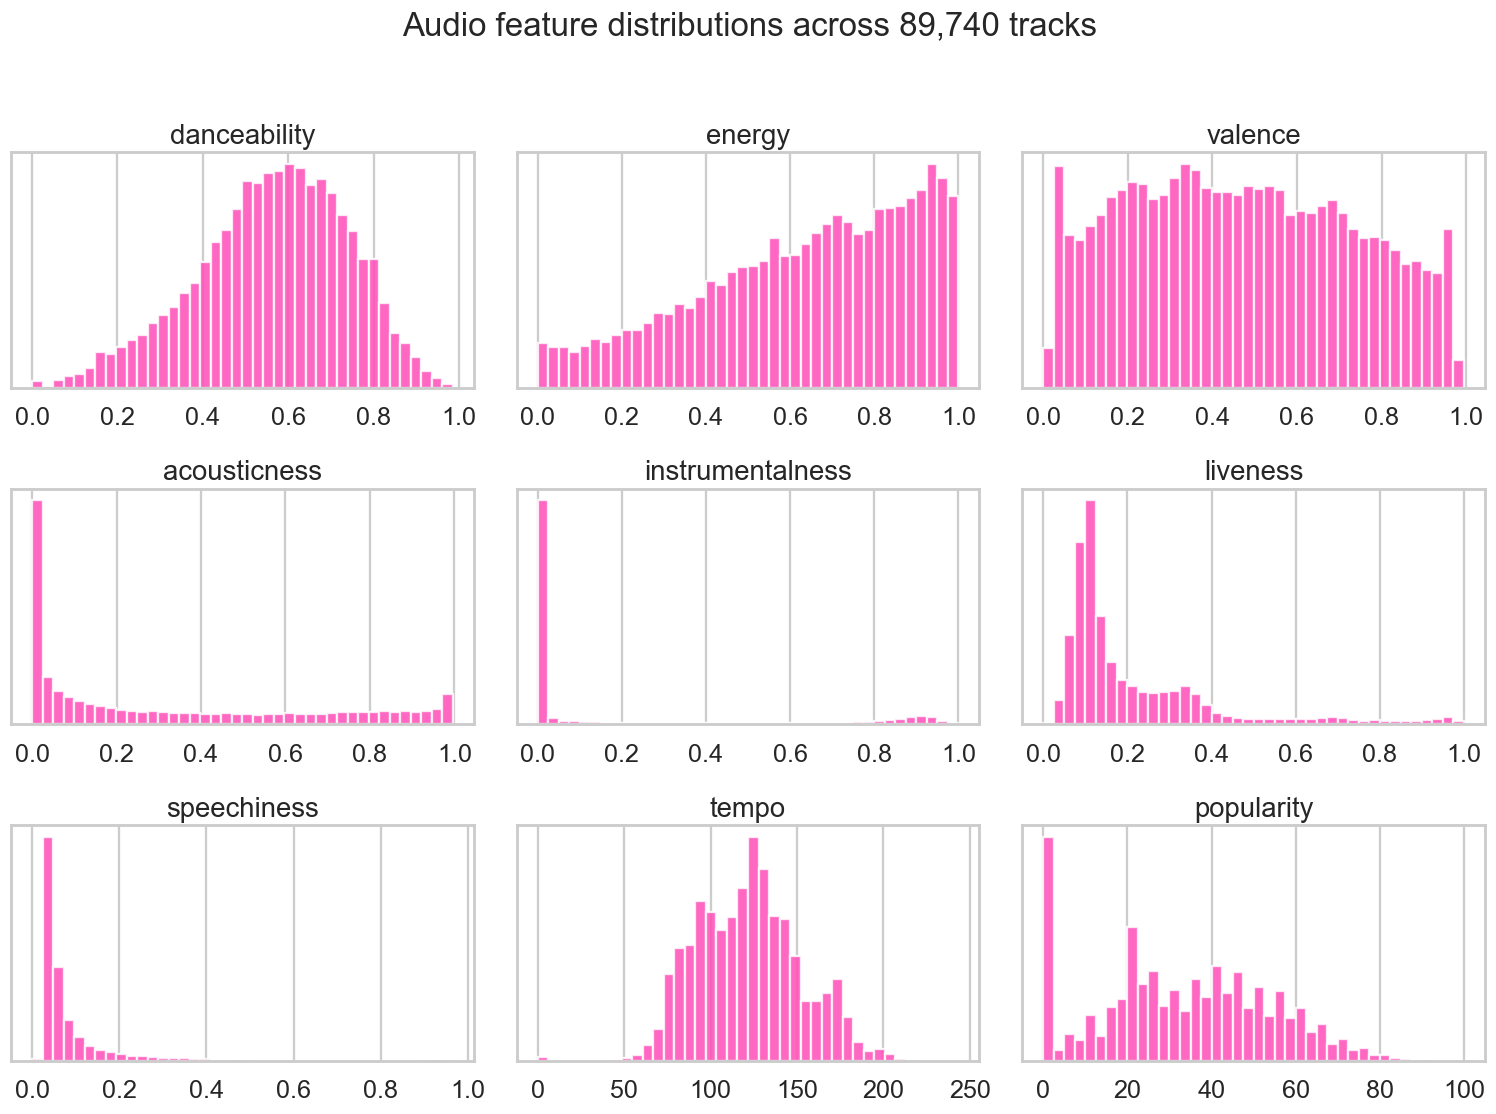

In [2]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flat, FEATURE_COLS):
    ax.hist(df[col], bins=40, color="#FF4DB8", edgecolor="white", alpha=0.85)
    ax.set_title(col)
    ax.set_yticks([])
fig.suptitle("Audio feature distributions across 89,740 tracks", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_feature_distributions.png", dpi=140, bbox_inches="tight")
plt.show()

## 2. Correlation heatmap

A small but mostly-uncorrelated feature set means the 9-D vector
isn't redundant — important for the MoodPrint petals and for the
MBTI 4 axes (we want the 4 axes to span fairly distinct directions).

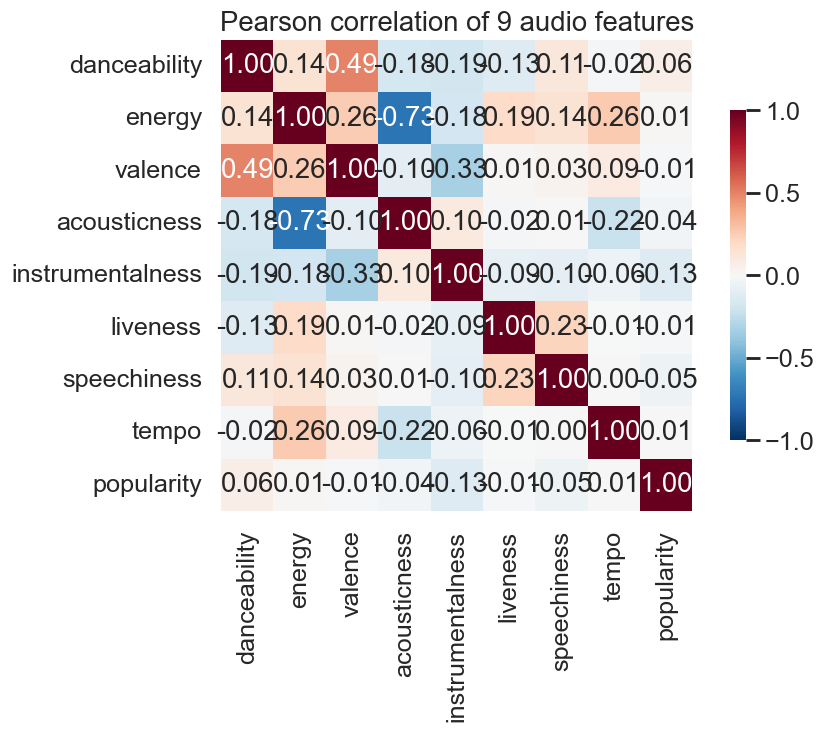

In [3]:
corr = df[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Pearson correlation of 9 audio features")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_correlation_heatmap.png", dpi=140, bbox_inches="tight")
plt.show()

## 3. Meta-genre composition

114 fine Spotify genres collapse into 12 broad meta-genres. The most
populated buckets (Electronic / Latin / Rock) dominate the Universe
pools and therefore the recommendation candidates.

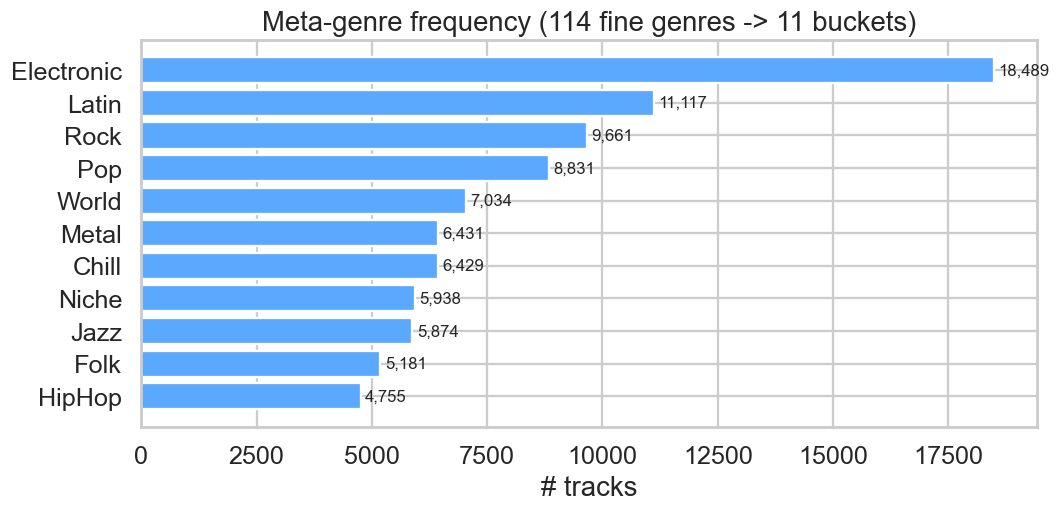

In [4]:
counts = df["meta_genre"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(counts.index, counts.values, color="#5BA8FF", edgecolor="white")
for i, v in enumerate(counts.values):
    ax.text(v + 100, i, f"{v:,}", va="center", fontsize=11)
ax.set_xlabel("# tracks")
ax.set_title("Meta-genre frequency (114 fine genres -> 11 buckets)")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_metagenre_distribution.png", dpi=140, bbox_inches="tight")
plt.show()

## 4. PCA 2-D global music map

40.5% of variance fits in 2 dimensions. The map is the basis of the
Insights tab in the Streamlit app: when a user uploads a playlist
their tracks are dropped on top of this scatter and you can see
where their taste lives globally.

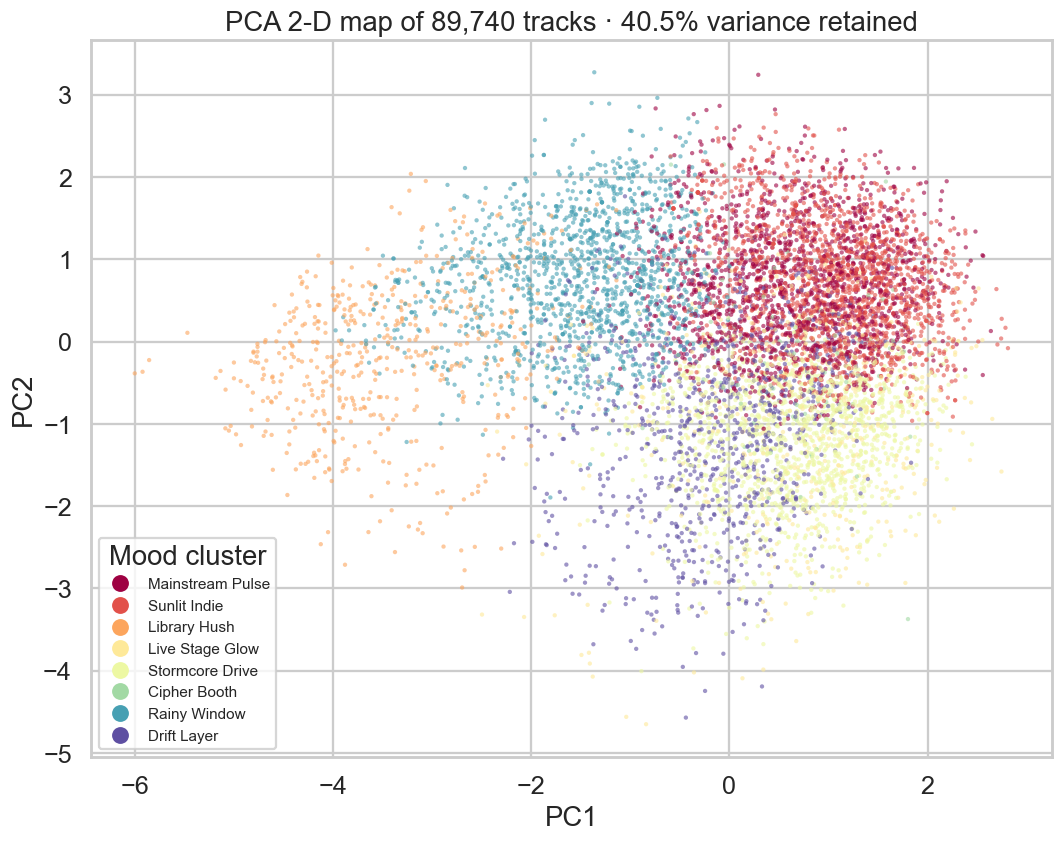

In [5]:
sample = df.sample(n=8000, random_state=0)
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(
    sample["pca_x"], sample["pca_y"],
    c=sample["mood_cluster"], cmap="Spectral",
    s=8, alpha=0.6, edgecolor="none",
)
import json
names = json.loads((MODELS_DIR / "mood_cluster_names.json").read_text())
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               color=plt.cm.Spectral(i / 7),
               markersize=10, label=names.get(str(i), f"C{i}"))
    for i in range(8)
]
ax.legend(handles=handles, title="Mood cluster", loc="lower left", fontsize=10)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA 2-D map of 89,740 tracks · 40.5% variance retained")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_pca_global_map.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. KMeans 8-centroid radar comparison

Each of the 8 mood clusters has a 9-dim signature in z-scored space.
The radar chart confirms the named clusters are mutually distinct
(e.g., `Cipher Booth` peaks on speechiness, `Library Hush` peaks on
acousticness/instrumentalness). This is the key model-layer figure.

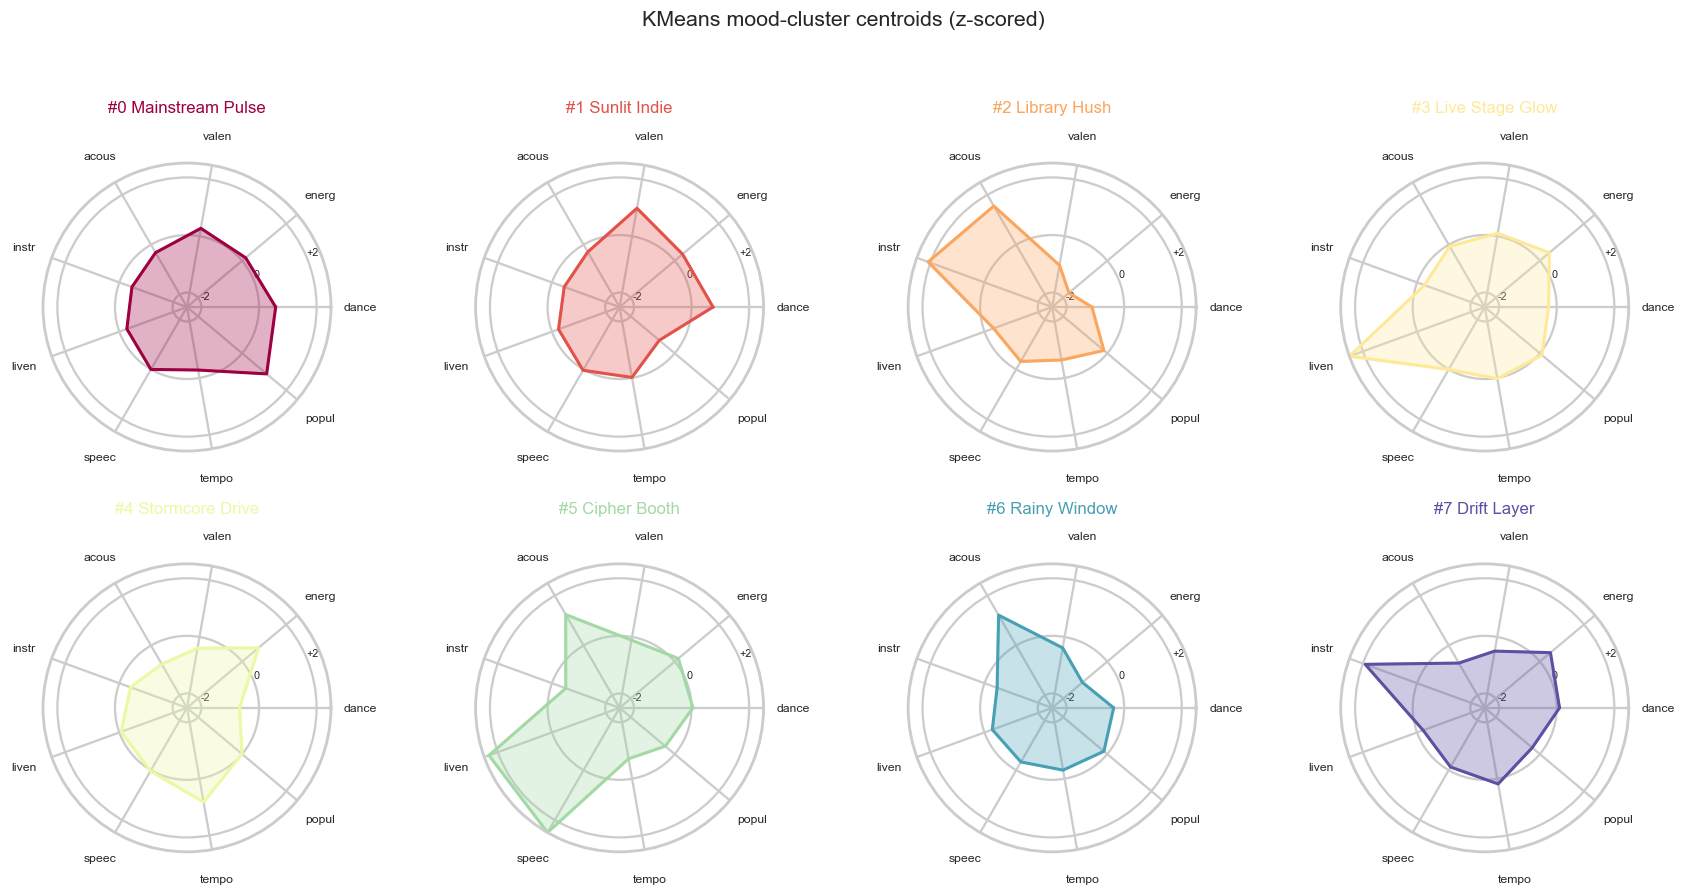

In [6]:
km = joblib.load(MOOD_KMEANS_PATH)
import json
cluster_names = json.loads((MODELS_DIR / "mood_cluster_names.json").read_text())

# Tempo z-scores can dominate the polar axis; clip for readability.
centers = np.clip(km.cluster_centers_, -2.5, 2.5)

n_axes = len(FEATURE_COLS)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                         subplot_kw=dict(projection="polar"))
for i, ax in enumerate(axes.flat):
    vals = centers[i].tolist() + [centers[i][0]]
    color = plt.cm.Spectral(i / 7)
    ax.plot(angles, vals, color=color, linewidth=2)
    ax.fill(angles, vals, color=color, alpha=0.30)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c[:5] for c in FEATURE_COLS], fontsize=8)
    ax.set_yticks([-2, 0, 2])
    ax.set_yticklabels(["-2", "0", "+2"], fontsize=7)
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f"#{i} {cluster_names[str(i)]}",
                 fontsize=11, color=color, pad=12)

fig.suptitle("KMeans mood-cluster centroids (z-scored)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_centroid_radars.png", dpi=140, bbox_inches="tight")
plt.show()

## Summary

Five figures saved under `../models/figures/`:

- `01_feature_distributions.png`
- `02_correlation_heatmap.png`
- `03_metagenre_distribution.png`
- `04_pca_global_map.png`
- `05_centroid_radars.png`

Drop them straight into the report's *Data Visualization* chapter.